Preprocessing

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)


url = 'https://raw.githubusercontent.com/bohkuri/spotify_songs_dataset/refs/heads/main/dataset.csv'
data = pd.read_csv(url)

#preprocessing
data = data.drop_duplicates()
data = data.dropna()

#simplify classes by grouping similar genres creating 9 distinct classes as opposed to the 114 present in the dataset
def map_genre(genre):
    genre = genre.lower()
    if any(i in genre for i in ['rock','alt','punk']):
        return 'Rock'
    elif any(i in genre for i in ['techno','house','edm','electro','trance','dubstep','club']):
        return 'Electronic'
    elif any(i in genre for i in ['pop']):
        return 'Pop'
    elif any(i in genre for i in ['classical','piano']):
        return 'Classical'
    elif any(i in genre for i in ['jazz','blues']):
        return 'Jazz'
    elif any(i in genre for i in ['r-n-b','soul']):
        return 'R&B'
    elif any(i in genre for i in ['latin','reggaeton']):
        return 'Latin'
    elif any(i in genre for i in ['metal']):
        return 'Metal'
    elif any(i in genre for i in ['country']):
        return 'Country'
    else:
        return None

#make new genre col
data['new_genre_assign'] = data['track_genre'].apply(map_genre)
data = data.dropna(subset=['new_genre_assign'])

#song features we use
features = ['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms','popularity']

X = data[features]

#use grouped genres as target instead and encode y
y = data['new_genre_assign']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Shared train/test split
# Used by both  random forest and logistic regression so the two models are evaluated on the exact same test set.
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Total samples after cleaning: {len(X)}")
print(f"Classes ({len(le.classes_)}): {list(le.classes_)}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print("\nClass distribution in full data:")
print(pd.Series(y).value_counts())


Total samples after cleaning: 46999
Classes (9): ['Classical', 'Country', 'Electronic', 'Jazz', 'Latin', 'Metal', 'Pop', 'R&B', 'Rock']
Train size: 37599, Test size: 9400

Class distribution in full data:
new_genre_assign
Electronic    13000
Rock          10000
Pop            8999
Metal          5000
Latin          3000
Jazz           2000
Classical      2000
R&B            2000
Country        1000
Name: count, dtype: int64


Random Forest

CV scores: [0.60893617 0.58106383 0.64776596 0.64606383 0.55569741]
Average Accuracy: 0.6079054403705237 
Std Dev: 0.03603369512024753
Balanced Accuracy: 0.6455764482431149

Overall Accuracy
Accuracy: 0.7059

Classification Report
              precision    recall  f1-score   support

   Classical       0.89      0.73      0.80       400
     Country       0.64      0.49      0.56       200
  Electronic       0.82      0.87      0.84      2600
        Jazz       0.52      0.44      0.48       400
       Latin       0.84      0.82      0.83       600
       Metal       0.72      0.74      0.73      1000
         Pop       0.62      0.64      0.63      1800
         R&B       0.52      0.45      0.49       400
        Rock       0.62      0.62      0.62      2000

    accuracy                           0.71      9400
   macro avg       0.69      0.65      0.66      9400
weighted avg       0.70      0.71      0.70      9400



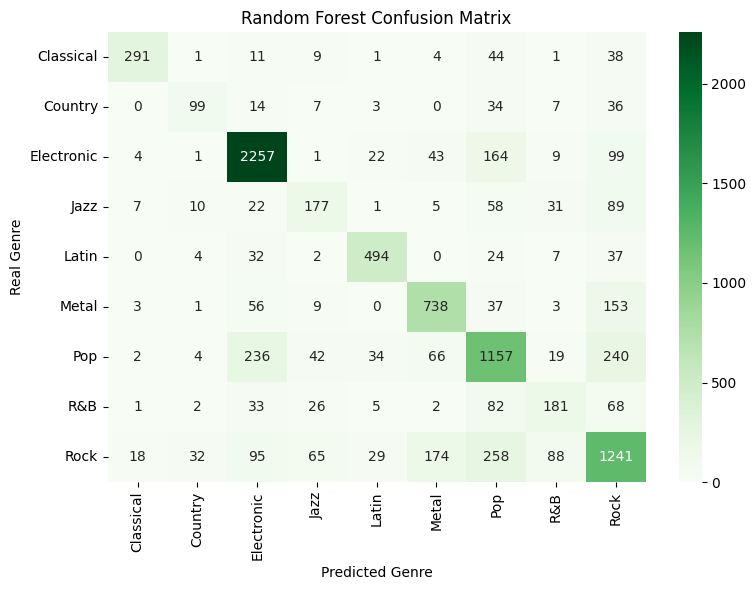

Feature Importance
             Feature  Importance
4       acousticness    0.148591
0       danceability    0.111447
10        popularity    0.103745
2           loudness    0.100588
1             energy    0.091476
3        speechiness    0.080299
5   instrumentalness    0.079195
9        duration_ms    0.078553
7            valence    0.076831
8              tempo    0.072193
6           liveness    0.057082


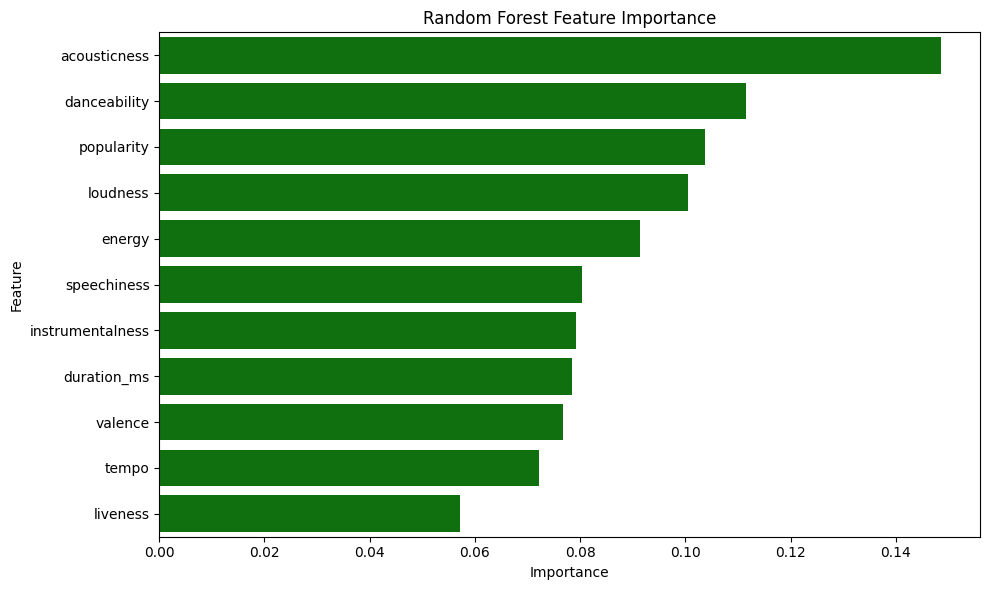

In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

#scaled x not required for random forest but included tp keep consistency with logistic regression
scaler = StandardScaler()
X_rf_train_scaled = scaler.fit_transform(X_train)
X_rf_test_scaled = scaler.transform(X_test)


#random forest
rf_classifier = RandomForestClassifier(n_estimators=120, max_depth=20, n_jobs=-1, class_weight='balanced_subsample', random_state=42)

#rand forest train
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)

#model evals
#for avg accuracy // 5fold cross val
scores_rf = cross_val_score(rf_classifier, X, y_encoded, cv=5, scoring='accuracy', n_jobs=-1)
print("CV scores:", scores_rf)
print("Average Accuracy:", scores_rf.mean(), "\nStd Dev:", scores_rf.std())

#for balanced acc
balanced_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)
print("Balanced Accuracy:", balanced_acc_rf)

#for overall accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("\nOverall Accuracy")
print(f"Accuracy: {accuracy_rf:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

#conf matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("Real Genre")
plt.tight_layout()
plt.show()

#feature importance
feature_imp_rf = pd.DataFrame({'Feature': features, 'Importance': rf_classifier.feature_importances_}).sort_values(by='Importance', ascending=False)

print("Feature Importance")
print(feature_imp_rf)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_rf, color='green')
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


Logistic Regression

In [ ]:
# Logistic Regression
# Uses the same X_train/X_test/y_train/y_test from the shared split above.

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_classifier = LogisticRegression(max_iter=2000, class_weight='balanced', solver='lbfgs', n_jobs=-1)

# 5 fold cv
log_pipeline = Pipeline([('scaler', StandardScaler()), ('logistic', log_classifier)])
scores_log = cross_val_score(log_pipeline, X, y_encoded, cv=5, scoring='accuracy', n_jobs=-1)
print("CV scores:", scores_log)
print("Average Accuracy:", scores_log.mean(), "\nStd Dev:", scores_log.std())

# Scale features for the single train/test fit
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and predict
log_classifier.fit(X_train_scaled, y_train)
y_pred_log = log_classifier.predict(X_test_scaled)

# Balanced accuracy
balanced_acc_log = balanced_accuracy_score(y_test, y_pred_log)
print("Balanced Accuracy:", balanced_acc_log)

# Overall accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)
print("\nOverall Accuracy")
print(f"Accuracy: {accuracy_log:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_log, target_names=le.classes_))


CV scores: [0.45851064 0.44670213 0.40829787 0.44531915 0.41504415]
Average Accuracy: 0.4347747881734815 
Std Dev: 0.01953028706201803
Balanced Accuracy: 0.48823646723646724

Overall Accuracy
Accuracy: 0.4668

Classification Report
              precision    recall  f1-score   support

   Classical       0.58      0.66      0.62       400
     Country       0.10      0.46      0.17       200
  Electronic       0.82      0.55      0.66      2600
        Jazz       0.25      0.43      0.32       400
       Latin       0.36      0.74      0.49       600
       Metal       0.52      0.82      0.63      1000
         Pop       0.49      0.32      0.39      1800
         R&B       0.12      0.15      0.13       400
        Rock       0.47      0.26      0.33      2000

    accuracy                           0.47      9400
   macro avg       0.41      0.49      0.42      9400
weighted avg       0.54      0.47      0.48      9400



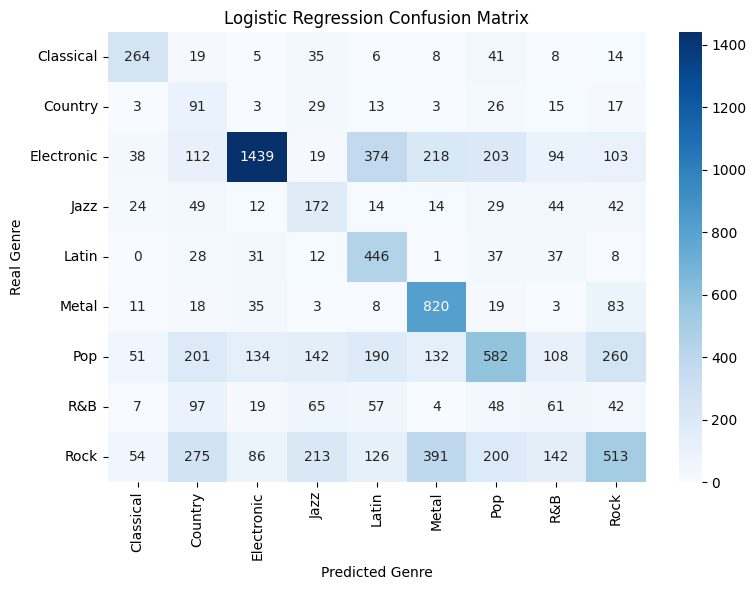

Feature Importance
             Feature  Importance
0       danceability    0.711076
5   instrumentalness    0.654653
4       acousticness    0.532725
1             energy    0.474727
2           loudness    0.394021
7            valence    0.387532
3        speechiness    0.268382
10        popularity    0.248211
9        duration_ms    0.137687
8              tempo    0.116007
6           liveness    0.056279


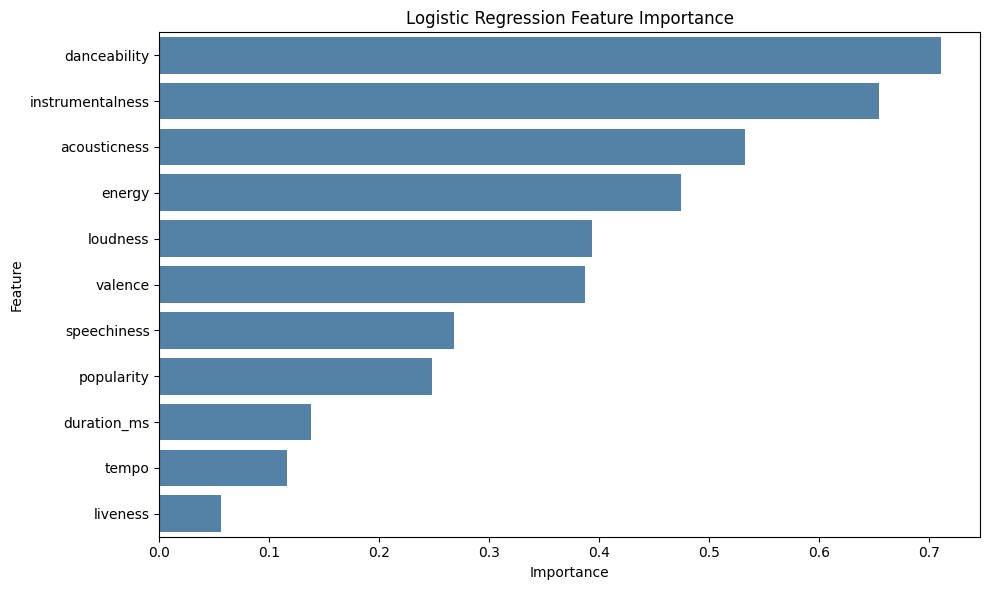

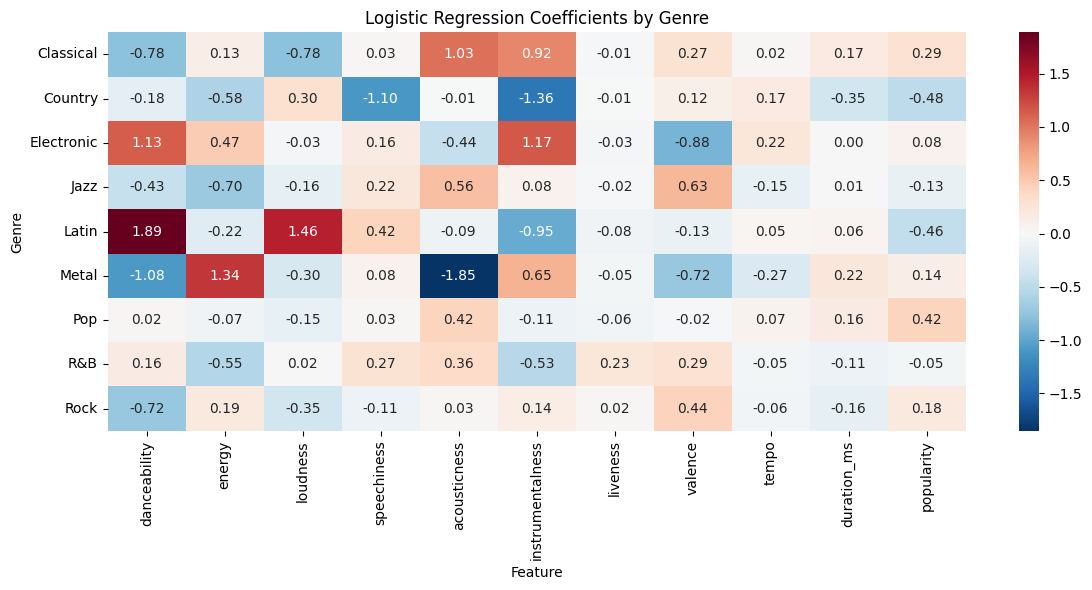

In [ ]:


# Logistic Regression confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("Real Genre")
plt.tight_layout()
plt.show()

# Feature importance
coef_abs_mean = np.mean(np.abs(log_classifier.coef_), axis=0)
feature_imp_log = pd.DataFrame({'Feature': features, 'Importance': coef_abs_mean}).sort_values(by='Importance', ascending=False)

print("Feature Importance")
print(feature_imp_log)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_log, color='steelblue')
plt.title("Logistic Regression Feature Importance")
plt.tight_layout()
plt.show()

coef_df = pd.DataFrame(log_classifier.coef_, columns=features, index=le.classes_)
plt.figure(figsize=(12, 6))
sns.heatmap(coef_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title("Logistic Regression Coefficients by Genre")
plt.xlabel("Feature")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()
